# 📐 Linear Algebra for ML
### Part of the *Math for ML* section — ML-CaPsule

> **Goal:** Understand the linear algebra that powers neural networks and sklearn's `LinearRegression` — with zero hand-waving.

---

## 🗺️ What you'll learn

| Concept | ML Connection |
|---|---|
| Vectors | Feature vectors — every data row is one |
| Matrices | Weight matrices in neural networks |
| Dot Product | How similarity and prediction scores are computed |
| Matrix Multiplication | How a neural network layer transforms its input |
| Transposition | Used in the Normal Equation inside `sklearn.LinearRegression` |

---

## 📺 Watch first (optional but highly recommended)
[3Blue1Brown — Essence of Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)  
Chapters 1–4 give the geometric intuition. This notebook gives you the code to go with it.

---
## 1️⃣ Vectors

### Concept
A **vector** is an ordered list of numbers. In ML, each row of your dataset is a feature vector.

$$\vec{x} = \begin{bmatrix} 2.5 \\ 1.3 \\ 4.0 \end{bmatrix}$$

This could represent one house: `[size=2.5, bedrooms=1.3, age=4.0]`.

**Geometric intuition:** A vector is an arrow in space. Its direction and length (magnitude) both carry meaning.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A feature vector for one data point (e.g., a house)
house = np.array([2.5, 1.3, 4.0])  # size, bedrooms, age
print("Feature vector (one house):", house)
print("Shape:", house.shape)  # (3,) means 3 features

# Vector magnitude (length) — used in similarity measures
magnitude = np.linalg.norm(house)
print(f"Magnitude (L2 norm): {magnitude:.3f}")

Feature vector (one house): [2.5 1.3 4. ]
Shape: (3,)
Magnitude (L2 norm): 4.893


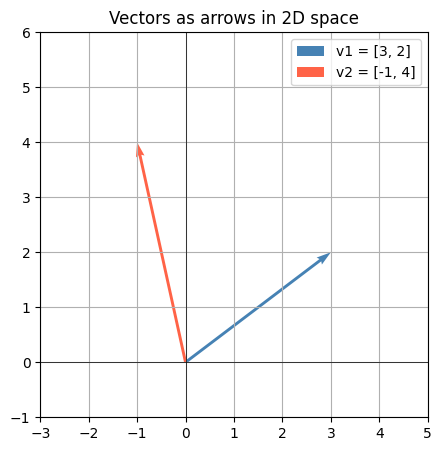

In [2]:
# Visualise 2D vectors
fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, 3, 2, angles='xy', scale_units='xy', scale=1, color='steelblue', label='v1 = [3, 2]')
ax.quiver(0, 0, -1, 4, angles='xy', scale_units='xy', scale=1, color='tomato', label='v2 = [-1, 4]')
ax.set_xlim(-3, 5); ax.set_ylim(-1, 6)
ax.axhline(0, color='k', linewidth=0.5); ax.axvline(0, color='k', linewidth=0.5)
ax.set_title('Vectors as arrows in 2D space')
ax.legend(); plt.grid(True); plt.show()

---
## 2️⃣ Matrices

### Concept
A **matrix** is a 2D array of numbers — a grid. In ML:
- Your **entire dataset** `X` is a matrix of shape `(n_samples, n_features)`
- **Weight matrices** in neural networks transform inputs from one layer to the next

$$W = \begin{bmatrix} 0.2 & 0.8 \\ -0.5 & 1.1 \\ 0.3 & -0.4 \end{bmatrix}$$

This weight matrix has shape `(3, 2)` — it maps 2 inputs to 3 neurons.

In [3]:
# The dataset X — every row is one sample, every column is one feature
X = np.array([
    [2.5, 1.3, 4.0],   # house 1
    [3.0, 2.0, 1.5],   # house 2
    [1.8, 1.0, 8.0],   # house 3
    [4.5, 3.0, 2.0],   # house 4
])

print("Dataset matrix X:")
print(X)
print(f"\nShape: {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features")

# A weight matrix W — imagine this is one layer of a neural network
# Maps 3 features → 2 hidden neurons
W = np.array([
    [0.2, -0.5],
    [0.8,  1.1],
    [0.3, -0.4]
])
print("\nWeight matrix W (3 features → 2 neurons):")
print(W)
print(f"Shape: {W.shape}")

Dataset matrix X:
[[2.5 1.3 4. ]
 [3.  2.  1.5]
 [1.8 1.  8. ]
 [4.5 3.  2. ]]

Shape: (4, 3)  →  4 samples, 3 features

Weight matrix W (3 features → 2 neurons):
[[ 0.2 -0.5]
 [ 0.8  1.1]
 [ 0.3 -0.4]]
Shape: (3, 2)


---
## 3️⃣ Dot Product

### Concept
The **dot product** of two vectors multiplies corresponding elements and sums them:

$$\vec{a} \cdot \vec{b} = a_1 b_1 + a_2 b_2 + a_3 b_3$$

**ML connection:** When a linear model predicts, it computes a dot product:
$$\hat{y} = \vec{w} \cdot \vec{x} + b = w_1 x_1 + w_2 x_2 + \ldots$$

The dot product is also a **similarity measure** — two vectors pointing in the same direction have a large positive dot product.

In [4]:
# Model weights and a single feature vector
weights = np.array([0.5, 0.3, -0.1])   # learned weights
bias    = 1.2
x_new   = np.array([3.0, 2.0, 1.5])   # one new house

# Manual dot product
manual_pred = sum(w * x for w, x in zip(weights, x_new)) + bias
print(f"Manual dot product prediction: {manual_pred:.3f}")

# NumPy dot product
np_pred = np.dot(weights, x_new) + bias
print(f"np.dot prediction:             {np_pred:.3f}")

# Why similarity matters — cosine similarity
a = np.array([1.0, 2.0])
b = np.array([2.0, 4.0])  # same direction as a
c = np.array([-2.0, 1.0]) # perpendicular to a

cos_ab = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
cos_ac = np.dot(a, c) / (np.linalg.norm(a) * np.linalg.norm(c))
print(f"\nCosine similarity a·b: {cos_ab:.3f}  (same direction → 1.0)")
print(f"Cosine similarity a·c: {cos_ac:.3f}  (perpendicular → 0.0)")

Manual dot product prediction: 3.150
np.dot prediction:             3.150

Cosine similarity a·b: 1.000  (same direction → 1.0)
Cosine similarity a·c: 0.000  (perpendicular → 0.0)


---
## 4️⃣ Matrix Multiplication

### Concept
Matrix multiplication `A @ B` computes the dot product of each **row of A** with each **column of B**.

$$C = A \cdot B \quad \text{where } C_{ij} = \sum_k A_{ik} \cdot B_{kj}$$

**ML connection:** A forward pass through a neural network layer is exactly matrix multiplication:
$$Z = X \cdot W + b$$

Where `X` has shape `(batch, features)` and `W` has shape `(features, neurons)`, giving `Z` shape `(batch, neurons)`.

In [5]:
# Neural network forward pass — one dense layer
# X: 4 samples, 3 features
# W: 3 features → 2 neurons
# b: bias for each neuron

X = np.array([
    [2.5, 1.3, 4.0],
    [3.0, 2.0, 1.5],
    [1.8, 1.0, 8.0],
    [4.5, 3.0, 2.0],
])

W = np.array([
    [0.2, -0.5],
    [0.8,  1.1],
    [0.3, -0.4]
])

b = np.array([0.1, -0.2])  # one bias per neuron

# Forward pass
Z = X @ W + b   # (4, 3) @ (3, 2) = (4, 2)

print(f"X shape: {X.shape}")
print(f"W shape: {W.shape}")
print(f"Z = X @ W + b shape: {Z.shape}  ← 4 samples, each now has 2 neuron activations")
print("\nPre-activation outputs Z:")
print(np.round(Z, 3))

# Rule check: inner dimensions must match!
# (4, 3) @ (3, 2) ✓   inner dims are both 3
# (4, 3) @ (2, 3) ✗   would fail

X shape: (4, 3)
W shape: (3, 2)
Z = X @ W + b shape: (4, 2)  ← 4 samples, each now has 2 neuron activations

Pre-activation outputs Z:
[[ 2.84 -1.62]
 [ 2.75 -0.1 ]
 [ 3.66 -3.2 ]
 [ 4.    0.05]]


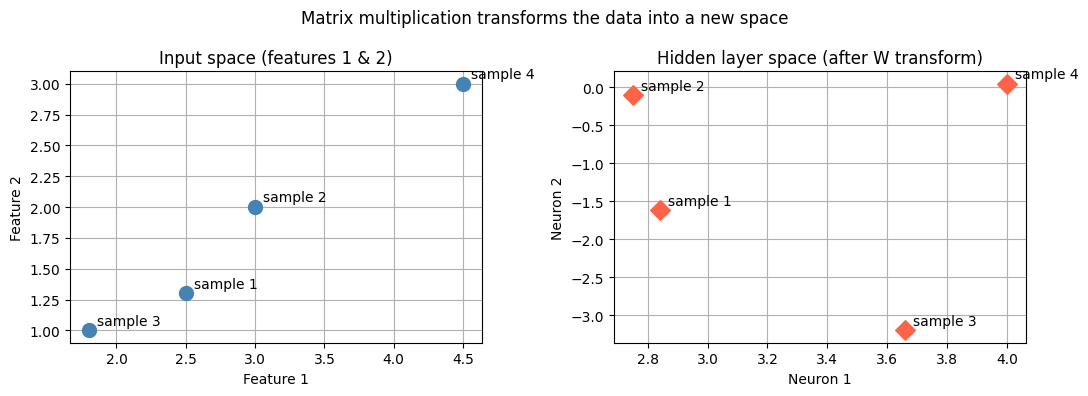

In [6]:
# Visualise what matrix multiplication does geometrically
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: input feature space (first 2 features)
axes[0].scatter(X[:, 0], X[:, 1], c='steelblue', s=100, zorder=3)
for i, (xi, yi) in enumerate(zip(X[:, 0], X[:, 1])):
    axes[0].annotate(f'sample {i+1}', (xi, yi), textcoords='offset points', xytext=(6, 4))
axes[0].set_title('Input space (features 1 & 2)')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].grid(True)

# Right: transformed hidden-layer space
axes[1].scatter(Z[:, 0], Z[:, 1], c='tomato', s=100, marker='D', zorder=3)
for i, (zi0, zi1) in enumerate(zip(Z[:, 0], Z[:, 1])):
    axes[1].annotate(f'sample {i+1}', (zi0, zi1), textcoords='offset points', xytext=(6, 4))
axes[1].set_title('Hidden layer space (after W transform)')
axes[1].set_xlabel('Neuron 1'); axes[1].set_ylabel('Neuron 2')
axes[1].grid(True)

plt.suptitle('Matrix multiplication transforms the data into a new space', fontsize=12)
plt.tight_layout(); plt.show()

---
## 5️⃣ Transposition

### Concept
The **transpose** of a matrix flips it over its diagonal — rows become columns:

$$A = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \end{bmatrix} \quad \Rightarrow \quad A^T = \begin{bmatrix} 1 & 4 \\ 2 & 5 \\ 3 & 6 \end{bmatrix}$$

**ML connection — the Normal Equation:**  
When you call `sklearn.LinearRegression().fit(X, y)`, under the hood it solves:

$$\hat{\theta} = (X^T X)^{-1} X^T y$$

This is the **closed-form solution** to linear regression — no gradient descent needed! Every transpose and matrix inverse in that formula is real NumPy linear algebra.

In [7]:
# Transposition
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print("A:\n", A)
print("A.T (transposed):\n", A.T)
print(f"\nA shape: {A.shape} → A.T shape: {A.T.shape}")

A:
 [[1 2 3]
 [4 5 6]]
A.T (transposed):
 [[1 4]
 [2 5]
 [3 6]]

A shape: (2, 3) → A.T shape: (3, 2)


In [ ]:
 # The Normal Equation — what sklearn LinearRegression does internally 
from sklearn.linear_model import LinearRegression

# Simple 1D dataset: house size → price
np.random.seed(42)
X_data = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
y_data = np.array([1.5, 3.1, 4.8, 6.2, 8.0])

# --- Method 1: Normal Equation from scratch ---
X_b = np.c_[np.ones((len(X_data), 1)), X_data]  # add bias column
theta_normal = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_data
print("Normal Equation solution:")
print(f"  bias (intercept): {theta_normal[0]:.4f}")
print(f"  weight (slope):   {theta_normal[1]:.4f}")

# --- Method 2: sklearn ---
model = LinearRegression().fit(X_data, y_data)
print("\nsklearn LinearRegression solution:")
print(f"  bias (intercept): {model.intercept_:.4f}")
print(f"  weight (slope):   {model.coef_[0]:.4f}")

print("\nBoth methods give the same answer — sklearn uses the Normal Equation internally!")

Normal Equation solution:
  bias (intercept): -0.1100
  weight (slope):   1.6100

sklearn LinearRegression solution:
  bias (intercept): -0.1100
  weight (slope):   1.6100

Both methods give the same answer — sklearn uses the Normal Equation internally!


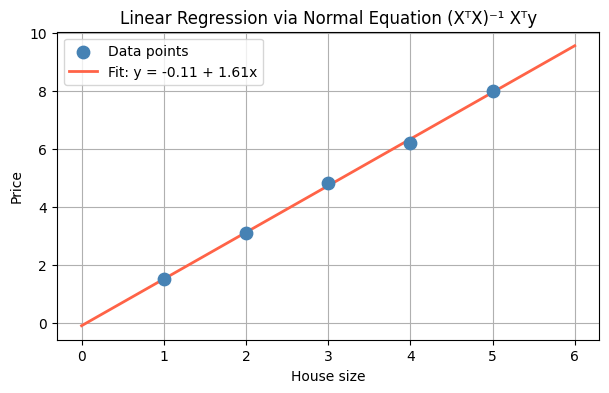

In [11]:
# Plot the result
x_plot = np.linspace(0, 6, 100)
y_plot = theta_normal[0] + theta_normal[1] * x_plot

plt.figure(figsize=(7, 4))
plt.scatter(X_data, y_data, color='steelblue', s=80, label='Data points', zorder=3)
plt.plot(x_plot, y_plot, color='tomato', linewidth=2, label=f'Fit: y = {theta_normal[0]:.2f} + {theta_normal[1]:.2f}x')
plt.xlabel('House size'); plt.ylabel('Price')
plt.title('Linear Regression via Normal Equation (X\u1d40X)\u207b\u00b9 X\u1d40y')
plt.legend(); plt.grid(True); plt.show()

---
## 🔗 What comes next?

You now know the linear algebra behind:
- How data flows through neural network layers (`X @ W + b`)
- How `sklearn.LinearRegression` solves for weights without iteration

**Next notebook:** [02_Calculus_for_ML.ipynb](02_Calculus_for_ML.ipynb) — learn the derivatives and chain rule that make the **GradientDescent/** folder in this repo work.

---

## 📝 Summary

| Concept | NumPy | ML use |
|---|---|---|
| Vector | `np.array([...])` | Feature vector per sample |
| Matrix | `np.array([[...]])` | Dataset, weight matrices |
| Dot product | `np.dot(a, b)` | Prediction score = w·x + b |
| Matrix multiply | `A @ B` | Neural net forward pass |
| Transpose | `A.T` | Normal Equation, backprop |

---
📺 **Deepen your intuition:** [3Blue1Brown — Essence of Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)